In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol with an attacker, to demonstrate that the attacker can be detected.

In [ ]:
def quantum_random_bit():
    """Generate a single random bit using a quantum measurement.
    Prepares |+> = (1/sqrt(2))(|0> + |1>) and measures it."""
    qc = QuantumCircuit(1, 1)
    qc.h(0)          
    qc.measure(0, 0)
    
    simulator = BasicSimulator()
    transpiled = transpile(qc, simulator)
    result = simulator.run(transpiled, shots=1).result()
    counts = result.get_counts()
    measured_bit = int(list(counts.keys())[0])
    return measured_bit

def quantum_random_bits(n):
    """Generate n random bits using quantum measurements."""
    return [quantum_random_bit() for _ in range(n)]

print("Generating 10 quantum random bits:")
test_bits = quantum_random_bits(10)
print(test_bits)

Generating 10 quantum random bits:
[1, 1, 0, 1, 0, 1, 0, 0, 0, 0]


In [32]:
NUM_QUBITS = 100  
THRESHOLD = 0.1    

print(f"BB84 Protocol Simulation (WITH Attacker)")
print(f"Number of qubits: {NUM_QUBITS}")
print(f"Detection threshold: {THRESHOLD*100}%")

BB84 Protocol Simulation (WITH Attacker)
Number of qubits: 100
Detection threshold: 10.0%


In [33]:
print("ALICE: Generating random bits and bases...")
alice_bits = quantum_random_bits(NUM_QUBITS)
alice_bases = quantum_random_bits(NUM_QUBITS)

print(f"Alice's bits  (first 20): {alice_bits[:20]}")
print(f"Alice's bases (first 20): {alice_bases[:20]}")
print(f"(0 = standard basis, 1 = diagonal basis)")

ALICE: Generating random bits and bases...
Alice's bits  (first 20): [0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1]
Alice's bases (first 20): [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1]
(0 = standard basis, 1 = diagonal basis)


ALICE: Encoding qubits and sending to Bob (via public quantum channel)...

Example: Alice's qubit 0 circuit (bit=0, basis=standard):


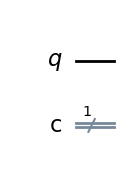

In [34]:
def alice_encode_qubits(bits, bases):
    encoded_qubits = []
    for i in range(len(bits)):
        qc = QuantumCircuit(1, 1)
        
        if bits[i] == 1:
            qc.x(0)  
        
      
        if bases[i] == 1:
            qc.h(0)  
        
        encoded_qubits.append(qc)
    return encoded_qubits

print("ALICE: Encoding qubits and sending to Bob (via public quantum channel)...")
alice_qubits = alice_encode_qubits(alice_bits, alice_bases)

print("\nExample: Alice's qubit 0 circuit (bit={}, basis={}):".format(
    alice_bits[0], 'diagonal' if alice_bases[0] == 1 else 'standard'))
alice_qubits[0].draw('mpl')

In [35]:
def eve_intercept_resend(qubits):
    simulator = BasicSimulator()
    eve_bases = quantum_random_bits(len(qubits))
    eve_results = []
    intercepted_qubits = []
    
    for i in range(len(qubits)):
        qc_measure = qubits[i].copy()
        
        if eve_bases[i] == 1:
            qc_measure.h(0) 
        
        qc_measure.measure(0, 0)
        
        transpiled = transpile(qc_measure, simulator)
        result = simulator.run(transpiled, shots=1).result()
        counts = result.get_counts()
        eve_bit = int(list(counts.keys())[0])
        eve_results.append(eve_bit)
        
        qc_resend = QuantumCircuit(1, 1)
        
        if eve_bit == 1:
            qc_resend.x(0)
        
        if eve_bases[i] == 1:
            qc_resend.h(0) 
        
        intercepted_qubits.append(qc_resend)
    
    return intercepted_qubits, eve_bases, eve_results

print("EVE: Intercepting qubits from the quantum channel...")
print("EVE: Measuring each qubit in a random basis...")
print("EVE: Re-encoding and forwarding qubits to Bob...")

eve_qubits, eve_bases, eve_results = eve_intercept_resend(alice_qubits)

print(f"\nEve's bases   (first 20): {eve_bases[:20]}")
print(f"Eve's results (first 20): {eve_results[:20]}")

eve_correct_basis = sum(e == a for e, a in zip(eve_bases, alice_bases))
print(f"\nEve guessed Alice's basis correctly: {eve_correct_basis}/{NUM_QUBITS} ({100*eve_correct_basis/NUM_QUBITS:.1f}%)")

EVE: Intercepting qubits from the quantum channel...
EVE: Measuring each qubit in a random basis...
EVE: Re-encoding and forwarding qubits to Bob...

Eve's bases   (first 20): [1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1]
Eve's results (first 20): [0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1]

Eve guessed Alice's basis correctly: 46/100 (46.0%)


In [36]:
def bob_measure_qubits(qubits, bob_bases):
    bob_results = []
    simulator = BasicSimulator()
    
    for i in range(len(qubits)):
        qc = qubits[i].copy()
        
        # If Bob chose the diagonal basis, apply H before measuring
        if bob_bases[i] == 1:
            qc.h(0)
        
        qc.measure(0, 0)
        
        transpiled = transpile(qc, simulator)
        result = simulator.run(transpiled, shots=1).result()
        counts = result.get_counts()
        measured_bit = int(list(counts.keys())[0])
        bob_results.append(measured_bit)
    
    return bob_results

print("BOB: Choosing random measurement bases...")
bob_bases = quantum_random_bits(NUM_QUBITS)

print("BOB: Measuring qubits (actually Eve's re-sent qubits)...")
bob_results = bob_measure_qubits(eve_qubits, bob_bases)

print(f"Bob's bases   (first 20): {bob_bases[:20]}")
print(f"Bob's results (first 20): {bob_results[:20]}")

BOB: Choosing random measurement bases...
BOB: Measuring qubits (actually Eve's re-sent qubits)...
Bob's bases   (first 20): [0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
Bob's results (first 20): [0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0]


In [37]:
def sift_keys(alice_bits, alice_bases, bob_results, bob_bases):
    alice_key = []
    bob_key = []
    matching_indices = []
    
    for i in range(len(alice_bits)):
        if alice_bases[i] == bob_bases[i]: 
            alice_key.append(alice_bits[i])
            bob_key.append(bob_results[i])
            matching_indices.append(i)
    
    return alice_key, bob_key, matching_indices

print("PUBLIC DISCUSSION: Comparing bases...")
alice_key, bob_key, matching_indices = sift_keys(alice_bits, alice_bases, bob_results, bob_bases)

print(f"\nTotal qubits sent: {NUM_QUBITS}")
print(f"Matching bases:    {len(matching_indices)} ({100*len(matching_indices)/NUM_QUBITS:.1f}%)")
print(f"\nAlice's sifted key (first 20): {alice_key[:20]}")
print(f"Bob's sifted key   (first 20): {bob_key[:20]}")

PUBLIC DISCUSSION: Comparing bases...

Total qubits sent: 100
Matching bases:    48 (48.0%)

Alice's sifted key (first 20): [0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1]
Bob's sifted key   (first 20): [0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0]


In [38]:
def verify_and_detect(alice_key, bob_key, threshold, sample_fraction=0.5):
    n = len(alice_key)
    sample_size = max(1, int(n * sample_fraction))
    
    # Use the first sample_size bits for verification
    sample_alice = alice_key[:sample_size]
    sample_bob = bob_key[:sample_size]
    
    # Count errors
    errors = sum(a != b for a, b in zip(sample_alice, sample_bob))
    error_rate = errors / sample_size if sample_size > 0 else 0
    
    # The remaining bits would form the final key (if no attacker detected)
    final_key_alice = alice_key[sample_size:]
    final_key_bob = bob_key[sample_size:]
    
    return final_key_alice, final_key_bob, errors, error_rate, sample_size

print("VERIFICATION: Comparing a subset of the sifted key...")
final_key_alice, final_key_bob, errors, error_rate, sample_size = verify_and_detect(
    alice_key, bob_key, THRESHOLD)

print(f"\nSample size for verification: {sample_size}")
print(f"Errors found: {errors}")
print(f"Error rate: {error_rate:.4f} ({error_rate*100:.2f}%)")
print(f"Detection threshold: {THRESHOLD*100}%")

if error_rate > THRESHOLD:
    print(f"\nEAVESDROPPER DETECTED!")
    print(f"Error rate ({error_rate*100:.2f}%) exceeds threshold ({THRESHOLD*100}%).")
    print(f"The quantum channel has been compromised.")
    print(f"Alice and Bob ABORT the key exchange. The key is NOT used.")
else:
    print(f"\n Error rate is below threshold.")
    print(f"   No eavesdropper detected (unlikely with an active attacker).")

VERIFICATION: Comparing a subset of the sifted key...

Sample size for verification: 24
Errors found: 9
Error rate: 0.3750 (37.50%)
Detection threshold: 10.0%

EAVESDROPPER DETECTED!
Error rate (37.50%) exceeds threshold (10.0%).
The quantum channel has been compromised.
Alice and Bob ABORT the key exchange. The key is NOT used.


In [29]:
print("DETAILED ANALYSIS OF EVE'S ATTACK:")

# For each position in the sifted key, check what happened
eve_correct = 0
eve_wrong = 0
errors_when_eve_correct = 0
errors_when_eve_wrong = 0

for idx in matching_indices:
    if eve_bases[idx] == alice_bases[idx]:
        eve_correct += 1
        if alice_bits[idx] != bob_results[idx]:
            errors_when_eve_correct += 1
    else:
        eve_wrong += 1
        if alice_bits[idx] != bob_results[idx]:
            errors_when_eve_wrong += 1

print(f"\nIn the sifted key ({len(matching_indices)} bits where Alice & Bob used same basis):")
print(f"")
print(f"Eve used CORRECT basis: {eve_correct} times")
print(f"-> Errors introduced: {errors_when_eve_correct} (should be around 0)")
print(f"")
print(f"Eve used WRONG basis:   {eve_wrong} times")
print(f"-> Errors introduced: {errors_when_eve_wrong} (should be ~{eve_wrong//2})")
print(f"")
total_sifted_errors = sum(a != b for a, b in zip(alice_key, bob_key))
print(f"Total errors in full sifted key: {total_sifted_errors}/{len(matching_indices)}")
print(f"Full sifted key error rate: {total_sifted_errors/len(matching_indices)*100:.2f}%")
print(f"")
print(f"Theory predicts 25% error rate with intercept-resend attack.")
print(f"This is because Eve guesses the wrong basis 50% of the time,")
print(f"and when she does, she introduces an error 50% of the time.")
print(f"50% × 50% = 25% overall error rate in the sifted key.")

DETAILED ANALYSIS OF EVE'S ATTACK:

In the sifted key (48 bits where Alice & Bob used same basis):

Eve used CORRECT basis: 21 times
-> Errors introduced: 0 (should be around 0)

Eve used WRONG basis:   27 times
-> Errors introduced: 9 (should be ~13)

Total errors in full sifted key: 9/48
Full sifted key error rate: 18.75%

Theory predicts 25% error rate with intercept-resend attack.
This is because Eve guesses the wrong basis 50% of the time,
and when she does, she introduces an error 50% of the time.
50% × 50% = 25% overall error rate in the sifted key.


In [ ]:
print("EVE'S KNOWLEDGE OF THE SIFTED KEY:")

eve_knows = 0
eve_wrong_bits = 0

for i, idx in enumerate(matching_indices):
    if eve_bases[idx] == alice_bases[idx]:
        if eve_results[idx] == alice_bits[idx]:
            eve_knows += 1
        else:
            eve_wrong_bits += 1  
    else:
        if eve_results[idx] == alice_bits[idx]:
            eve_knows += 1  
        else:
            eve_wrong_bits += 1

print(f"Sifted key length: {len(matching_indices)}")
print(f"Bits Eve got correct: {eve_knows} ({100*eve_knows/len(matching_indices):.1f}%)")
print(f"Bits Eve got wrong:   {eve_wrong_bits} ({100*eve_wrong_bits/len(matching_indices):.1f}%)")
print(f"")
print(f"Eve knows 75% of the key bits on average, but she doesn't know")
print(f"WHICH bits she got right or wrong, making the key unreliable for her.")
print(f"")
print(f"More importantly, Alice and Bob detected the attack and will")
print(f"DISCARD this key entirely, so Eve's knowledge is worthless.")

EVE'S KNOWLEDGE OF THE SIFTED KEY:
Sifted key length: 48
Bits Eve got correct: 36 (75.0%)
Bits Eve got wrong:   12 (25.0%)

Eve knows ~75% of the key bits on average, but she doesn't know
WHICH bits she got right or wrong — making the key unreliable for her.

More importantly, Alice and Bob detected the attack and will
DISCARD this key entirely, so Eve's knowledge is worthless.


In [25]:
print("SIDE-BY-SIDE COMPARISON (first 30 sifted key bits):")
print(f"{'Index':>5}  {'Alice':>5}  {'Bob':>5}  {'Match':>5}  {'Eve basis':>10}  {'Eve correct?':>12}")
print("-" * 60)

display_count = min(30, len(matching_indices))
for i in range(display_count):
    idx = matching_indices[i]
    match = 'YES' if alice_key[i] == bob_key[i] else 'NO'
    eve_basis_str = 'std' if eve_bases[idx] == 0 else 'diag'
    eve_correct_str = 'YES' if eve_bases[idx] == alice_bases[idx] else 'NO'
    print(f"{idx:>5}  {alice_key[i]:>5}  {bob_key[i]:>5}  {match:>5}  {eve_basis_str:>10}  {eve_correct_str:>12}")

print(f"\n(Showing {display_count} of {len(matching_indices)} sifted key positions)")
print(f"\nNotice: errors (✗) tend to occur when Eve used the WRONG basis.")

SIDE-BY-SIDE COMPARISON (first 30 sifted key bits):
Index  Alice    Bob  Match   Eve basis  Eve correct?
------------------------------------------------------------
    0      0      1     NO        diag            NO
    2      0      0    YES         std           YES
    4      1      1    YES         std           YES
   10      1      1    YES        diag            NO
   11      1      0     NO        diag            NO
   13      1      0     NO         std            NO
   15      0      0    YES         std            NO
   19      1      1    YES         std            NO
   22      0      0    YES        diag           YES
   23      1      1    YES        diag            NO
   26      1      1    YES        diag           YES
   28      1      1    YES        diag           YES
   30      0      0    YES        diag           YES
   31      0      0    YES         std           YES
   33      1      0     NO         std            NO
   34      0      0    YES        diag 